# Experimento 2: DINOv2 solo (imagen)
**Estrategia:** Linear probe — backbone DINOv2 ViT-L/14 congelado + capa lineal entrenable  
**Dataset:** PAD-UFES-20 — clasificación binaria (maligno vs benigno)  
**Referencia:** Effendie & Aguiar-Pulido (2024) — DINOv2 congelado sobre PAD-UFES-20

## 0. Setup

In [1]:
!pip install timm -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision.transforms as T

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo: cuda
GPU: Tesla T4


## 1. Configuración de rutas

In [4]:
BASE_PATH    = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
IMGS_DIR     = os.path.join(BASE_PATH, 'images')
RESULTS_PATH = os.path.join(BASE_PATH, 'resultados')
os.makedirs(RESULTS_PATH, exist_ok=True)

img_index = {}
for part in ['imgs_part_1', 'imgs_part_2', 'imgs_part_3']:
    part_path = os.path.join(IMGS_DIR, part)
    for fname in os.listdir(part_path):
        img_index[fname] = os.path.join(part_path, fname)

print(f'Imágenes indexadas: {len(img_index)}')

Imágenes indexadas: 2298


## 2. Cargar splits

In [5]:
df_train = pd.read_csv(os.path.join(BASE_PATH, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(BASE_PATH, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(BASE_PATH, 'split_test.csv'))

for df in [df_train, df_val, df_test]:
    df['img_path'] = df['img_id'].map(img_index)

# Cargar labels ya guardados del experimento CLIP
y_train = np.load(os.path.join(RESULTS_PATH, 'y_train.npy'))
y_val   = np.load(os.path.join(RESULTS_PATH, 'y_val.npy'))
y_test  = np.load(os.path.join(RESULTS_PATH, 'y_test.npy'))

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print(f'Labels cargados')

Train: 1838 | Val: 230 | Test: 230
Labels cargados ✅


## 3. Cargar DINOv2

In [6]:
# DINOv2 ViT-L/14 — mismo tamaño que CLIP para comparación justa
dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14')
dino_model = dino_model.to(device)
dino_model.eval()

# Congelar backbone
for param in dino_model.parameters():
    param.requires_grad = False

# Preprocesamiento estándar DINOv2 (ImageNet stats)
dino_preprocess = T.Compose([
    T.Resize(224),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

print('DINOv2 ViT-L/14 cargado y congelado')
print('Dimensión del embedding: 1024')

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitl14_pretrain.pth


100%|██████████| 1.13G/1.13G [00:07<00:00, 153MB/s] 


DINOv2 ViT-L/14 cargado y congelado ✅
Dimensión del embedding: 1024


## 4. Dataset

In [7]:
class SkinDataset(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['img_path']).convert('RGB')
        img   = self.transform(img)
        label = torch.tensor(row['label'], dtype=torch.float32)
        return img, label

## 5. Pre-extraer embeddings DINOv2 (una sola vez)

In [8]:
def extract_dino_embeddings(df, dino_model, preprocess, device, batch_size=64):
    dataset    = SkinDataset(df, preprocess)
    loader     = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    embeddings = []
    dino_model.eval()
    with torch.no_grad():
        for imgs, _ in tqdm(loader):
            imgs  = imgs.to(device)
            feats = dino_model(imgs)   # CLS token [B, 1024]
            feats = feats / feats.norm(dim=-1, keepdim=True)
            embeddings.append(feats.cpu().numpy())
    return np.concatenate(embeddings)

dino_train_path = os.path.join(RESULTS_PATH, 'dino_X_train.npy')

if os.path.exists(dino_train_path):
    print('Embeddings DINOv2 ya existen, cargando...')
    X_train = np.load(os.path.join(RESULTS_PATH, 'dino_X_train.npy'))
    X_val   = np.load(os.path.join(RESULTS_PATH, 'dino_X_val.npy'))
    X_test  = np.load(os.path.join(RESULTS_PATH, 'dino_X_test.npy'))
else:
    print('Extrayendo embeddings DINOv2 (solo ocurre una vez)...')
    print('Train...')
    X_train = extract_dino_embeddings(df_train, dino_model, dino_preprocess, device)
    print('Val...')
    X_val   = extract_dino_embeddings(df_val,   dino_model, dino_preprocess, device)
    print('Test...')
    X_test  = extract_dino_embeddings(df_test,  dino_model, dino_preprocess, device)

    np.save(os.path.join(RESULTS_PATH, 'dino_X_train.npy'), X_train)
    np.save(os.path.join(RESULTS_PATH, 'dino_X_val.npy'),   X_val)
    np.save(os.path.join(RESULTS_PATH, 'dino_X_test.npy'),  X_test)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

Extrayendo embeddings DINOv2 (solo ocurre una vez)...
Train...


  0%|          | 0/29 [00:00<?, ?it/s]

Val...


  0%|          | 0/4 [00:00<?, ?it/s]

Test...


  0%|          | 0/4 [00:00<?, ?it/s]

✅ X_train: (1838, 1024) | X_val: (230, 1024) | X_test: (230, 1024)


## 6. DataLoaders sobre embeddings

In [9]:
X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32)
X_v  = torch.tensor(X_val,   dtype=torch.float32)
y_v  = torch.tensor(y_val,   dtype=torch.float32)
X_te = torch.tensor(X_test,  dtype=torch.float32)
y_te = torch.tensor(y_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_v,  y_v),  batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=64, shuffle=False)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 29 | Val: 4 | Test: 4


## 7. Cabeza lineal entrenable

In [10]:
# DINOv2 ViT-L/14 produce embeddings de 1024 dimensiones
head = nn.Sequential(
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 1)
).to(device)

trainable = sum(p.numel() for p in head.parameters())
print(f'Parámetros entrenables: {trainable:,}')

Parámetros entrenables: 262,657


## 8. Entrenamiento

In [12]:
EPOCHS    = 30
LR        = 1e-3
THRESHOLD = 0.5
PATIENCE  = 10

criterion       = nn.BCEWithLogitsLoss()
optimizer       = torch.optim.Adam(head.parameters(), lr=LR, weight_decay=1e-4)
scheduler       = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
best_val_auc    = 0
patience_count  = 0
best_model_path = os.path.join(RESULTS_PATH, 'dino_solo_head.pt')
history         = {'train_loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(EPOCHS):
    head.train()
    train_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(head(X_b).squeeze(1), y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    head.eval()
    val_loss, val_probs, val_labels = 0, [], []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out       = head(X_b).squeeze(1)
            val_loss += criterion(out, y_b).item()
            val_probs.extend(torch.sigmoid(out).cpu().numpy())
            val_labels.extend(y_b.cpu().numpy())
    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(val_labels, val_probs)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    print(f'Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(head.state_dict(), best_model_path)
        patience_count = 0
        print(f'  Mejor modelo guardado (AUC={best_val_auc:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'  Early stopping en epoch {epoch+1}')
            break

print(f'\nMejor Val AUC: {best_val_auc:.4f}')

Epoch 01 | Train Loss: 0.2898 | Val Loss: 0.4038 | Val AUC: 0.9026
  Mejor modelo guardado (AUC=0.9026)
Epoch 02 | Train Loss: 0.2780 | Val Loss: 0.4018 | Val AUC: 0.9029
  Mejor modelo guardado (AUC=0.9029)
Epoch 03 | Train Loss: 0.2695 | Val Loss: 0.4012 | Val AUC: 0.9032
  Mejor modelo guardado (AUC=0.9032)
Epoch 04 | Train Loss: 0.2692 | Val Loss: 0.4330 | Val AUC: 0.9009
Epoch 05 | Train Loss: 0.2706 | Val Loss: 0.4015 | Val AUC: 0.9041
  Mejor modelo guardado (AUC=0.9041)
Epoch 06 | Train Loss: 0.2682 | Val Loss: 0.4236 | Val AUC: 0.9030
Epoch 07 | Train Loss: 0.2613 | Val Loss: 0.4290 | Val AUC: 0.9019
Epoch 08 | Train Loss: 0.2549 | Val Loss: 0.3954 | Val AUC: 0.9051
  Mejor modelo guardado (AUC=0.9051)
Epoch 09 | Train Loss: 0.2477 | Val Loss: 0.3966 | Val AUC: 0.9083
  Mejor modelo guardado (AUC=0.9083)
Epoch 10 | Train Loss: 0.2521 | Val Loss: 0.4140 | Val AUC: 0.9046
Epoch 11 | Train Loss: 0.2502 | Val Loss: 0.3992 | Val AUC: 0.9065
Epoch 12 | Train Loss: 0.2438 | Val Loss:

## 9. Curvas de entrenamiento

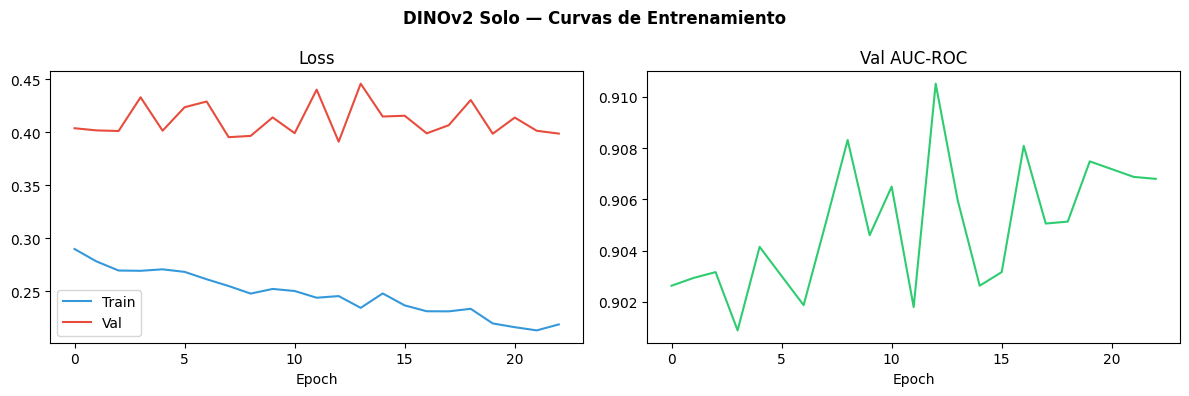

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train', color='#3498db')
axes[0].plot(history['val_loss'],   label='Val',   color='#e74c3c')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(history['val_auc'], color='#2ecc71')
axes[1].set_title('Val AUC-ROC')
axes[1].set_xlabel('Epoch')
plt.suptitle('DINOv2 Solo — Curvas de Entrenamiento', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'dino_solo_curvas.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluación en Test

In [14]:
head.load_state_dict(torch.load(best_model_path))
head.eval()

test_probs, test_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = head(X_b.to(device)).squeeze(1)
        test_probs.extend(torch.sigmoid(out).cpu().numpy())
        test_labels.extend(y_b.numpy())

test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)
test_preds  = (test_probs >= THRESHOLD).astype(int)

auc       = roc_auc_score(test_labels, test_probs)
accuracy  = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall    = recall_score(test_labels, test_preds)
f1        = f1_score(test_labels, test_preds)

print('=' * 50)
print('  RESULTADOS — DINOv2 SOLO (imagen)')
print('=' * 50)
print(f'  AUC-ROC   : {auc:.4f}')
print(f'  Accuracy  : {accuracy*100:.1f}%')
print(f'  Precision : {precision*100:.1f}%')
print(f'  Recall    : {recall*100:.1f}%')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 50)
print()
print(classification_report(test_labels, test_preds, target_names=['Benigno', 'Maligno']))

  RESULTADOS — DINOv2 SOLO (imagen)
  AUC-ROC   : 0.8675
  Accuracy  : 77.8%
  Precision : 74.4%
  Recall    : 81.8%
  F1-Score  : 0.7792

              precision    recall  f1-score   support

     Benigno       0.82      0.74      0.78       120
     Maligno       0.74      0.82      0.78       110

    accuracy                           0.78       230
   macro avg       0.78      0.78      0.78       230
weighted avg       0.78      0.78      0.78       230



## 11. Matriz de confusión

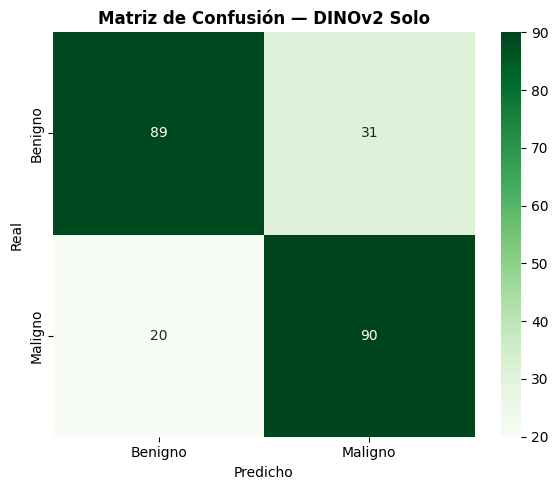

In [15]:
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'], ax=ax)
ax.set_title('Matriz de Confusión — DINOv2 Solo', fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'dino_solo_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Guardar resultados

In [17]:
results = {
    'modelo':    'DINOv2 solo (imagen)',
    'backbone':  'ViT-L/14 DINOv2',
    'auc':       round(auc, 4),
    'accuracy':  round(accuracy, 4),
    'precision': round(precision, 4),
    'recall':    round(recall, 4),
    'f1':        round(f1, 4),
}
results_path = os.path.join(RESULTS_PATH, 'resultados_dino_solo.csv')
pd.DataFrame([results]).to_csv(results_path, index=False)
print(f' Resultados guardados en: {results_path}')
print(pd.DataFrame([results]))

 Resultados guardados en: /content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20/resultados/resultados_dino_solo.csv
                 modelo         backbone     auc  accuracy  precision  recall  \
0  DINOv2 solo (imagen)  ViT-L/14 DINOv2  0.8675    0.7783     0.7438  0.8182   

       f1  
0  0.7792  
